<a href="https://colab.research.google.com/github/Harshithabr18/tteh/blob/main/creditcard_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("creditcard dataset.csv")
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
data.info()
data.describe()
data['Class'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39702 entries, 0 to 39701
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    39702 non-null  int64  
 1   V1      39702 non-null  float64
 2   V2      39702 non-null  float64
 3   V3      39702 non-null  float64
 4   V4      39702 non-null  float64
 5   V5      39702 non-null  float64
 6   V6      39702 non-null  float64
 7   V7      39702 non-null  float64
 8   V8      39702 non-null  float64
 9   V9      39702 non-null  float64
 10  V10     39702 non-null  float64
 11  V11     39702 non-null  float64
 12  V12     39702 non-null  float64
 13  V13     39701 non-null  float64
 14  V14     39701 non-null  float64
 15  V15     39701 non-null  float64
 16  V16     39701 non-null  float64
 17  V17     39701 non-null  float64
 18  V18     39701 non-null  float64
 19  V19     39701 non-null  float64
 20  V20     39701 non-null  float64
 21  V21     39701 non-null  float64
 22

,count
Class,
0.0,39597
1.0,104


In [ ]:
from sklearn.utils import resample

In [ ]:
from sklearn.model_selection import train_test_split

data.dropna(inplace=True)
X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.4f}')

Model Accuracy: 0.9997


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[7900   21]
 [  20    0]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      7921
         1.0       0.00      0.00      0.00        20

    accuracy                           0.99      7941
   macro avg       0.50      0.50      0.50      7941
weighted avg       0.99      0.99      0.99      7941



In [ ]:
from sklearn.metrics import roc_auc_score

roc_score = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.4986744097967428


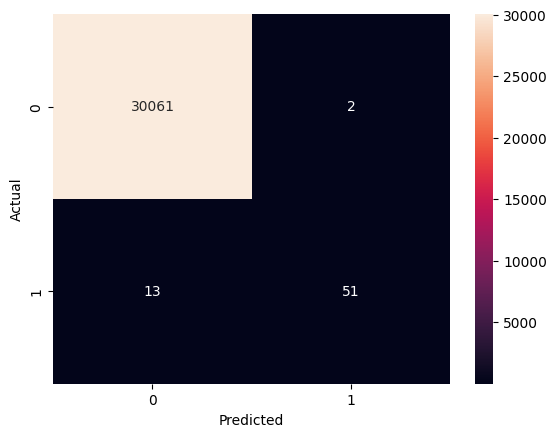

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Recalculate cm to ensure it's defined
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd
import os

# Define the expected file path
file_path = "creditcard dataset.csv"

# Assuming the file now exists, load it
data = pd.read_csv(file_path)
data.dropna(inplace=True)

# Define X and y
X = data.drop('Class', axis=1)
y = data['Class']

sm = SMOTE()
X_res, y_res = sm.fit_resample(X, y)
print("File loaded successfully and SMOTE applied.")

File loaded successfully and SMOTE applied.


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
import joblib
from sklearn.ensemble import RandomForestClassifier

# Re-initialize and train the model to ensure it is defined
# X_train and y_train are assumed to be available from previous steps
model = RandomForestClassifier()
model.fit(X_train, y_train)

joblib.dump(model, "fraud_model.pkl")
print("Model saved successfully as fraud_model.pkl")

Model saved successfully as fraud_model.pkl


In [ ]:
data = pd.read_csv("creditcard dataset.csv")
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
data.info()
data.describe()
data['Class'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150632 entries, 0 to 150631
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    150632 non-null  int64  
 1   V1      150632 non-null  float64
 2   V2      150632 non-null  float64
 3   V3      150632 non-null  float64
 4   V4      150632 non-null  float64
 5   V5      150632 non-null  float64
 6   V6      150632 non-null  float64
 7   V7      150632 non-null  float64
 8   V8      150631 non-null  float64
 9   V9      150631 non-null  float64
 10  V10     150631 non-null  float64
 11  V11     150631 non-null  float64
 12  V12     150631 non-null  float64
 13  V13     150631 non-null  float64
 14  V14     150631 non-null  float64
 15  V15     150631 non-null  float64
 16  V16     150631 non-null  float64
 17  V17     150631 non-null  float64
 18  V18     150631 non-null  float64
 19  V19     150631 non-null  float64
 20  V20     150631 non-null  float64
 21  V21     15

,count
Class,
0.0,150337
1.0,294


In [ ]:
from sklearn.utils import resample

In [13]:
from sklearn.model_selection import train_test_split

data.dropna(inplace=True)
X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.4f}')

Model Accuracy: 0.9995


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[30061     2]
 [   13    51]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     30063
         1.0       0.96      0.80      0.87        64

    accuracy                           1.00     30127
   macro avg       0.98      0.90      0.94     30127
weighted avg       1.00      1.00      1.00     30127



In [ ]:
from sklearn.metrics import roc_auc_score

roc_score = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.8984042365199746


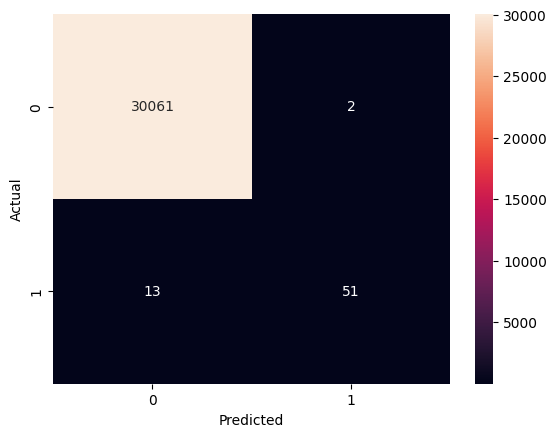

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd
import os

# Define the expected file path
file_path = "creditcard dataset.csv"

# Assuming the file now exists, load it
data = pd.read_csv(file_path)
data.dropna(inplace=True)

# Define X and y
X = data.drop('Class', axis=1)
y = data['Class']

sm = SMOTE()
X_res, y_res = sm.fit_resample(X, y)
print("File loaded successfully and SMOTE applied.")

File loaded successfully and SMOTE applied.


In [ ]:
from sklearn.model_selection import GridSearchCV

In [5]:
import joblib

# Split the resampled data into training and testing sets
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Train a new RandomForestClassifier on the resampled training data
resampled_model = RandomForestClassifier(random_state=42)
resampled_model.fit(X_train_res, y_train_res)

# Save the newly trained model
joblib.dump(resampled_model, "fraud_model.pkl")
print("Model trained on resampled data and saved as fraud_model.pkl")

Model trained on resampled data and saved as fraud_model.pkl


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Ensure data is split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ensure the model is defined and trained
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# new_data = pd.DataFrame([[...]]) # Replace with your new data, ensuring it has the same columns as X
# For demonstration, let's use a sample from X_test:
new_data = X_test.sample(1)
prediction = model.predict(new_data)
print(f"Prediction for new data:\n{new_data}\nClass: {prediction[0]}")

Prediction for new data:
         Time        V1        V2        V3       V4        V5        V6  \
105054  69343 -0.762399  1.222016  1.156858  0.49999  0.062246 -0.459416   

              V7        V8        V9  ...       V20       V21       V22  \
105054  0.385619  0.102991 -0.101903  ...  0.229364 -0.224698 -0.518847   

             V23       V24       V25       V26       V27       V28  Amount  
105054  0.063022  0.003124 -0.619689  0.208956  0.348398  0.285988    0.89  

[1 rows x 30 columns]
Class: 0.0
